<a href="https://colab.research.google.com/github/agarwal-ritika/coding-samples-/blob/main/Monthly_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instructions

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

#instructions
#still need to manually add EOL, KIX and Vietnam

#dates
date = '2023-07-01' # enter date of first day of period under evaluation
fystart = '2023-07-01' # here we enter fy start date
today = '2023-09-01' # enter cutoff date
before = '2020-01-01' # before this process started
CY2022Q4 = '2022-12-31'
CY2023Q1 = '2023-03-31'
CY2023Q2 = '2023-06-30'
#files
espig = pd.read_excel('/content/Implementation Grants (26).xlsx') # here we have espig file name
espig_pen = pd.read_excel('/content/Implementation Grants (26).xlsx') # here we have espig file name again
espig_act = pd.read_excel('/content/Implementation Grants (26).xlsx') # and again
scg = pd.read_excel('/content/ESPDG_SCG (16).xlsx') # here we have scg file name again
new_om = pd.read_excel('/content/New OM Pipeline.xlsx','Pre Grant_pipeline') # here we have pre-pipeline file name
heatmap = pd.read_excel('/content/New OM Pipeline.xlsx', 'Heatmap', header=6)
revision = pd.read_excel('/content/Revision (5).xlsx') # here we have the revision file
gpex_pipeline = pd.read_excel('/content/Pipeline (13).xlsx') # here we have the revision file
pdg = pd.read_excel('/content/PDG (10).xlsx') # here we have the pdg file
countrygpe = pd.read_excel('/content/Country GPE (7).xlsx') # here we have the countrygpe file
estimates = pd.read_excel('/content/Estimates tracker (2).xlsx', 'Pre Grant_pipeline_Target (ES)',header=6) # here we have the countrygpe file


#other
pd.options.display.float_format = '{:,}'.format
new_header = new_om.iloc[5] #grab the first row for the header
new_om = new_om[6:] #drop prior rows
new_om.columns = new_header #set the header row as the df header



/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


# New Section

Output on portfolio

In [ ]:
from pandas.core.groupby.groupby import Index

#approved grants

# below we extract espig grants approved since cuttoff

espig = espig[['Country Name','Grant ID', 'Grant Type','Grant Agent','Grant Approval Date','Grant Amount','Operating Model']]
espiglm = espig[espig['Grant Approval Date'] >= date]
espigfy = espig[espig['Grant Approval Date'] >= fystart]
espig_new_om = espig[espig['Operating Model'] == 2025]

# below we extract pdg grants approved since cuttoff

pdg = pdg[['Country Name','Grant ID','Grant Agent','Grant Approval Date','Grant Amount','Operating Model']]
pdg['Grant Type'] = 'PDG'
pdglm = pdg[pdg['Grant Approval Date'] >= date]
pdgfy = pdg[pdg['Grant Approval Date'] >= fystart]
pdg_new_om = pdg[pdg['Operating Model'] == 2025]

# below we extract revisions approved since cuttoff

# Selecting the needed columns
revision = revision[['Country Name','Grant ID', 'Grant Type','Grant Agent','Restructuring Request Decision Date','Additional Grant Amount','Additional Supervision Fee Amount']]

# Remove all rows where 'Additional Grant Amount' is 0
revision = revision[revision['Additional Grant Amount'] != 0]

# In cases where 'Grant Agent' is "WB" it adds the 'Additional Supervision Fee Amount' to the 'Additional Grant Amount'
revision.loc[revision['Grant Agent'] == 'WB', 'Additional Grant Amount'] += revision['Additional Supervision Fee Amount']

# Drop the 'Additional Supervision Fee Amount' column
revision = revision.drop('Additional Supervision Fee Amount', axis=1)

# Add "top up" to all instances under "Grant Type"
revision['Grant Type'] = revision['Grant Type'].apply(lambda x: x + ' top up')

revision = revision.rename(columns={'Additional Grant Amount': 'Grant Amount'})
revision = revision.rename(columns={'Restructuring Request Decision Date': 'Grant Approval Date'})

# Merging rows with the same 'Country Name', 'Grant Type', 'Grant Agent' and 'Grant Approval Date' and summing up 'Grant Amount'
revision = revision.groupby(['Country Name','Grant ID', 'Grant Type', 'Grant Agent', 'Grant Approval Date'], as_index=False)['Grant Amount'].sum()

# Adding a new 'Operating Model' column
revision['Operating Model'] = np.where((revision['Grant Approval Date'] >= '2022-01-01') & (~revision['Grant Type'].isin(['ESPIG (AF)', 'ESPIG', 'ESPIG (COVID-19 AF)'])), '2025', '')

revisionlm = revision[revision['Grant Approval Date'] >= date]
revisionfy = revision[revision['Grant Approval Date'] >= fystart]

revision_new_om = revision[revision['Operating Model'] == '2025']

#below we extract SCG grants approved since cutoff
scg = scg[['Country Name','Grant ID','Grant Type','Grant Agent','Grant Approval Date','Total Grant Amount', 'Operating Model']]
scg = scg[scg['Grant Type'] == 'SCG']
scg = scg.rename(columns={'Total Grant Amount': 'Grant Amount'})
scglm = scg[scg['Grant Approval Date'] >= date]
scgfy = scg[scg['Grant Approval Date'] >= fystart]
scg_new_om = scg[scg['Operating Model'] == 2025]

#below we merge all the approved grant types since last month
espiglm = pd.DataFrame(espiglm)
scglm = pd.DataFrame(scglm)
revisionlm = pd.DataFrame(revisionlm)
pdglm = pd.DataFrame(pdglm)
frameslm = [espiglm, scglm, revisionlm, pdglm]
merged_all_grants = pd.concat(frameslm)
merged_all_grants = merged_all_grants.reset_index(drop=True)

#below we merge all the approved grant types under new om except for top ups, which are already included in grant amounts
espig_all = pd.DataFrame(espig)
scg_all = pd.DataFrame(scg)
pdg_all = pd.DataFrame(pdg)
frames_all = [espig_all, scg_all, pdg_all]
merged_all = pd.concat(frames_all)
merged_all = merged_all.reset_index(drop=True)

#New OM grants approved since last month, except for top ups, which are already included in grant amounts
all_new_om_grants = merged_all[merged_all['Operating Model'] == 2025]

#below we merge all the approved grant types under new om, including top ups
espig_all = pd.DataFrame(espig)
scg_all = pd.DataFrame(scg)
pdg_all = pd.DataFrame(pdg)
revision_all = pd.DataFrame(revision)
frames_all_with_revision = [espig_all, scg_all, pdg_all, revision_all]
merged_all_with_revision = pd.concat(frames_all_with_revision)
merged_all_with_revision = merged_all_with_revision.reset_index(drop=True)

#2023 approvals

approvals_CY_2023 = merged_all_with_revision[(merged_all_with_revision['Grant Approval Date'] >= '2023-01-01') & (merged_all_with_revision['Grant Approval Date'] < '2024-01-01')]

approvals_FY_2023 = merged_all_with_revision[(merged_all_with_revision['Grant Approval Date'] >= '2022-07-01') & (merged_all_with_revision['Grant Approval Date'] < '2023-07-01')]

approvals_FY_2023_adjusted = merged_all_with_revision[(merged_all_with_revision['Grant Approval Date'] >= '2022-07-01') & (merged_all_with_revision['Grant Approval Date'] < '2023-07-01')]


# Identify rows with 'top up' in 'Grant Type'
mask_CY_2023 = (approvals_CY_2023.duplicated('Grant ID', keep=False)) & (approvals_CY_2023['Grant Type'].str.contains('top up'))
mask_FY_2023 = (approvals_FY_2023.duplicated('Grant ID', keep=False)) & (approvals_FY_2023['Grant Type'].str.contains('top up'))

# Drop these rows from the DataFrame
approvals_CY_2023 = approvals_CY_2023[~mask_CY_2023]
approvals_FY_2023 = approvals_FY_2023[~mask_FY_2023]

# Identify rows with 'top up' in 'Grant Type' and 'Grant ID' not in approvals_FY_2023

# Create a boolean mask for unique 'Grant ID's
unique_grant_mask = approvals_FY_2023_adjusted['Grant ID'].map(approvals_FY_2023_adjusted['Grant ID'].value_counts() == 1)

# Select rows where 'Grant Type' contains 'top up' and 'Grant ID' is unique
top_up_unique_grant = approvals_FY_2023_adjusted[
    (approvals_FY_2023_adjusted['Grant Type'].str.contains('top up')) &
    unique_grant_mask
]


#below we merge the approved espigs and scgs since start of fy
espigfy = pd.DataFrame(espigfy)
scgfy = pd.DataFrame(scgfy)
framesfy = [espigfy, scgfy]
merged_espig_scg_fy = pd.concat(framesfy)
merged_espig_scg_fy = merged_espig_scg_fy.reset_index(drop=True)

#below we create the pendings ESPIGs data
espig_pen = espig_pen[['Country Name', 'Grant Status', 'Grant Type','Grant Agent','Grant Approval Date','*Estimated Grant Start Date','Grant Amount']]
espig_pen = espig_pen[espig_pen['Grant Status'] == 'Pending']
espig_pen = espig_pen.reset_index(drop=True)
espig_pen['Months between approval and estimated start date'] = round(((espig_pen['*Estimated Grant Start Date'] - espig_pen['Grant Approval Date']).astype(int))/2626560000000000,1)

# Drop the 'Grant Status' column
espig_pen = espig_pen.drop('Grant Status', axis=1)


#below we create the active ESPIGs data
espig_act = espig_act[['Country Name', 'Grant Status', 'Grant Type','Grant Agent','Grant Approval Date','*Actual Grant Start Date','Grant Amount']]
espig_act = espig_act[espig_act['*Actual Grant Start Date'] >= date]
espig_act = espig_act.reset_index(drop=True)
espig_act['Months between approval and actual start date'] = round(((espig_act['*Actual Grant Start Date'] - espig_act['Grant Approval Date']).astype(int))/2626560000000000,1)

#new monthly dashboard
print("GRANT PORTFOLIO - APPROVALS")
print("   ")
print(f"{espiglm.shape[0]} implementation grants, worth {espiglm['Grant Amount'].sum():,} USD, and {scglm.shape[0]}  SCGs, worth {scglm['Grant Amount'].sum():,} USD, were approved since {date}. In addition, we also had {revisionlm.shape[0]} top ups  approved, worth {revisionlm['Grant Amount'].sum():,} USD.")
print("   ")
print(f"Under the new OM, {all_new_om_grants.shape[0]} grants ({espig_new_om.shape[0]} implementation grants, {scg_new_om.shape[0]} SCGs & {pdg_new_om.shape[0]} PDGs) worth {all_new_om_grants['Grant Amount'].sum():,} USD have been approved.")
print("   ")
print(f"In CY23, {approvals_CY_2023.shape[0]} grants were approved, worth {approvals_CY_2023['Grant Amount'].sum():,} USD.")
print("   ")
print(f"In FY23, {approvals_FY_2023.shape[0]} grants were approved, worth {approvals_FY_2023['Grant Amount'].sum():,} USD.")

#cohorts

espig_new_om

#below we print items

import matplotlib.ticker as ticker

total_approved = approvals_FY_2023['Grant Amount'].sum()
target = 1000000000
plt.rcParams["figure.figsize"] = [10, 2]
b1 = plt.barh("Approvals", total_approved,color='green')
b2 = plt.barh("Approvals", target - total_approved, left=total_approved,color='midnightblue')

# Adjust the formatter
formatter = ticker.FuncFormatter(lambda x, pos: f'{x / 1e9}')
plt.gca().xaxis.set_major_formatter(formatter)

# Add the values on the bars
plt.text(total_approved/2, 0, f'{total_approved / 1e9:.2f}', va='center', ha='center', color='white', fontsize=14)
plt.text(total_approved + (target - total_approved)/2, 0, f'{(target - total_approved) / 1e9:.2f}', va='center', ha='center', color='white', fontsize=14)

plt.legend([b1, b2], ["Cumulative approvals since July 1, 2022", "Remaining to reach 1bn target"], loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Amount (in billion USD)')  # Add x-axis label
plt.show()


print(f"Grants approved since {fystart}")
print("   ")
print(f"{approvals_FY_2023['Grant Amount'].sum():,} USD in grants has been approved so far.")
print("   ")
print(f"{espigfy.shape[0]} implementation grants were approved, worth {espigfy['Grant Amount'].sum():,} USD.")
print("   ")
print(f"{scgfy.shape[0]} SCGs were approved, worth {scgfy['Grant Amount'].sum():,} USD.")
print("   ")
print(f"{pdgfy.shape[0]} PDGs were approved, worth {pdgfy['Grant Amount'].sum():,} USD.")
print("   ")
print(f"{top_up_unique_grant.shape[0]} top ups were approved, worth {top_up_unique_grant['Grant Amount'].sum():,} USD.")
print("   ")
print(f"Grants effectiveness update since {date}")
print("   ")
print(f"{espig_pen.shape[0]} implementation grants are pending, worth {espig_pen['Grant Amount'].sum():,} USD.")
print("   ")
print(f"{espig_act.shape[0]} implementation grants became active, worth {espig_act['Grant Amount'].sum():,} USD.")
print("   ")
print(f"Pending implementation grants as of {today}")
print("   ")
display(espig_pen)


<ipython-input-2-86e672ced9e6>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdg['Grant Type'] = 'PDG'


TypeError: unsupported operand type(s) for -: 'str' and 'str'

Cohort progress

<ipython-input-5-cb56b4818844>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_om3['Cohort'] = new_om3['Cohort'].fillna('N/A')


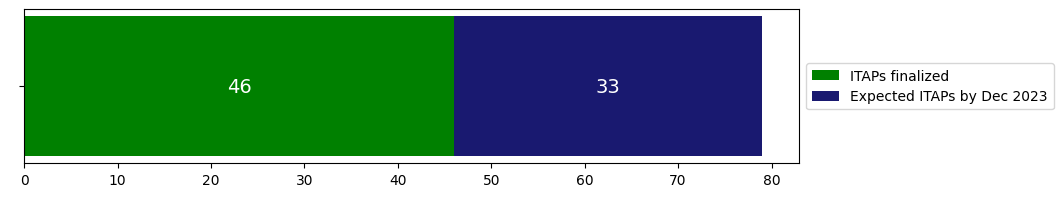

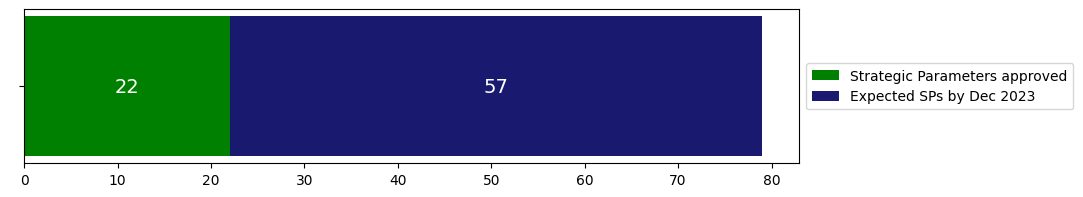

Since 2023-07-01, 5 countries have selected their grant agent. These are Cote d'Ivoire (STG), Senegal (MLT-STG), Somalia - Federal (STG-GEA), Somalia - Somaliland (STG-GEA), Tonga (MLT).


In [ ]:
new_om2 = new_om[['Country','Cohort','Cohort Start date','Deadline for application','Final Country Analytic ','Engagement memo Manager Meeting',' ITAP Assessment Finalized','QA of the strategic parameters of the draft Compact ','Approval of strategic parameters Letter sent to Gov/LEG']]
new_om2 = pd.DataFrame(new_om2)
cols = new_om2.columns[2:9]
new_om2[cols] = new_om2[cols].apply(pd.to_datetime, errors='coerce')
new_om3 = new_om2[['Country','Cohort',' ITAP Assessment Finalized','Approval of strategic parameters Letter sent to Gov/LEG']]
itap = new_om3[new_om3[' ITAP Assessment Finalized'] <= today]
sp = new_om3[new_om3['Approval of strategic parameters Letter sent to Gov/LEG'] <= today]
num_sp = (new_om3['Approval of strategic parameters Letter sent to Gov/LEG'] <= today).sum()
num_itap = (new_om3[' ITAP Assessment Finalized'] <= today).sum()

# Fill NaN values in 'Cohort' with 'N/A'
new_om3['Cohort'] = new_om3['Cohort'].fillna('N/A')

# Filter DataFrame to find rows where 'Cohort' is 'Multiplier' or 'N/A'
filtered_df = new_om3[new_om3['Cohort'].isin(['Multiplier', 'N/A'])]

# Iterate through filtered DataFrame and count rows where ' ITAP Assessment Finalized' is not 'NaT'
non_cohort_compacts = 0
for index, row in filtered_df.iterrows():
    if pd.notna(row[' ITAP Assessment Finalized']):
        non_cohort_compacts += 1



#charts

import matplotlib.pyplot as plt

def stacked_bar_chart_ITAP(num_itap):
    Y = 76 + non_cohort_compacts - num_itap

    plt.rcParams["figure.figsize"] = [10, 2]

    # Create the bar chart
    bar1 = plt.barh(' ', num_itap, color='green')
    bar2 = plt.barh(' ', Y, left=num_itap, color='midnightblue')

    # Label the x axis in increments of 10
    plt.xticks(range(0, 76+10, 10)) # Since total is 76 (num_itap + Y)

    # Add the values on the bar
    plt.text(num_itap/2, 0, str(num_itap), va='center', ha='center', color='white', fontsize=14)
    plt.text(num_itap + Y/2, 0, str(Y), va='center', ha='center', color='white', fontsize=14)

    # Add a legend to the right of the plot
    plt.legend((bar1[0], bar2[0]), ('ITAPs finalized', 'Expected ITAPs by Dec 2023'), bbox_to_anchor=(1, 0.5), loc='center left')

    plt.show()

def stacked_bar_chart_SP(num_sp):
    Y = 76 + non_cohort_compacts - num_sp

    plt.rcParams["figure.figsize"] = [10, 2]

    # Create the bar chart
    bar1 = plt.barh(' ', num_sp, color='green')
    bar2 = plt.barh(' ', Y, left=num_sp, color='midnightblue')

    # Label the x axis in increments of 10
    plt.xticks(range(0, 76+10, 10)) # Since total is 76 (num_sp + Y)

    # Add the values on the bar
    plt.text(num_sp/2, 0, str(num_sp), va='center', ha='center', color='white', fontsize=14)
    plt.text(num_sp + Y/2, 0, str(Y), va='center', ha='center', color='white', fontsize=14)

    # Add a legend to the right of the plot
    plt.legend((bar1[0], bar2[0]), ('Strategic Parameters approved', 'Expected SPs by Dec 2023'), bbox_to_anchor=(1, 0.5), loc='center left')

    plt.show()

# Call the functions with sample data
stacked_bar_chart_ITAP(num_itap)
stacked_bar_chart_SP(num_sp)

#pipeline

import pandas as pd

# Assuming gpex_pipeline is your DataFrame and 'date' is your label storing the date
mask = gpex_pipeline['Actual GA selection completion (date) (FGO-GO)'] >= date
Y = mask.sum()

# Creating the list of country names with their corresponding Grant Type
Z = ', '.join(gpex_pipeline.loc[mask].apply(lambda row: f"{row['Country Name']} ({row['Grant Type(FGO-GO)']})", axis=1))

output = f"Since {date}, {Y} countries have selected their grant agent. These are {Z}."
print(output)












Program development

In [ ]:
import pandas as pd
from IPython.display import display

def process_data(espig, new_om):
    # Filter the espig dataframe
    espig_filtered = espig[espig['Grant Type'].str.contains('STG') &
                           (espig['Grant Type'] != 'STG (AF)')]

    # Merge the espig and new_om dataframes
    merged = pd.merge(espig_filtered, new_om, how='inner',
                      left_on='Country Name', right_on='Country')

    # Make sure dates are in datetime format
    merged['Grant Approval Date'] = pd.to_datetime(merged['Grant Approval Date'])
    merged['Approval of strategic parameters Letter sent to Gov/LEG'] = pd.to_datetime(merged['Approval of strategic parameters Letter sent to Gov/LEG'])

    # Calculate the difference in months, with days accounted as fractions of month
    merged['Program Development'] = ((merged['Grant Approval Date'].dt.year - merged['Approval of strategic parameters Letter sent to Gov/LEG'].dt.year) * 12
                                     + merged['Grant Approval Date'].dt.month - merged['Approval of strategic parameters Letter sent to Gov/LEG'].dt.month
                                     + (merged['Grant Approval Date'].dt.day - merged['Approval of strategic parameters Letter sent to Gov/LEG'].dt.day) / 30)

    # Round to 1 decimal place
    merged['Program Development'] = merged['Program Development'].round(1)

    # Create a new dataframe with specific columns
    new_table = merged[['Country Name', 'Cohort', 'Approval of strategic parameters Letter sent to Gov/LEG',
                        'Grant Approval Date', 'Program Development']]

    return new_table

# Assuming espig and new_om are your dataframes
new_table = process_data(espig, new_om)

# Display the new_table dataframe
display(new_table)

# Create a second table by grouping by 'Cohort' and calculating the mean of 'Program Development'
second_table = new_table.groupby('Cohort')['Program Development'].mean().reset_index()

# Create a dataframe with all cohorts
all_cohorts = pd.DataFrame({'Cohort': ['Cohort1 (pilot)', 'Cohort2', 'Cohort3', 'Cohort4', 'Cohort5']})

# Merge all_cohorts with second_table
second_table = pd.merge(all_cohorts, second_table, how='left', on='Cohort')

# Replace NaN values with 'TBD'
second_table.fillna('TBD', inplace=True)

# Rename the column
second_table.columns = ['Cohort', 'Program Development (manual)']

print("   ")

# Display the second table
display(second_table)






,Country Name,Cohort,Approval of strategic parameters Letter sent to Gov/LEG,Grant Approval Date,Program Development
0,Kenya,Cohort1 (pilot),2022-04-05,2022-11-23 00:00:21,7.6
1,Nepal,Cohort1 (pilot),2022-07-25,2023-01-31 00:00:21,6.2
2,Sierra Leone,Cohort2,2022-11-23,2023-07-28 00:00:21,8.2
3,Tajikistan,Cohort1 (pilot),2022-05-04,2023-07-28 00:00:21,14.8
4,Tanzania - Mainland,Cohort2,2022-11-23,2023-05-30 00:00:21,6.2
5,Zimbabwe,Cohort2,2023-01-31,2023-07-28 00:00:00,5.9


,Cohort,Program Development (manual)
0,Cohort1 (pilot),9.533333333333333
1,Cohort2,6.766666666666667
2,Cohort3,TBD
3,Cohort4,TBD
4,Cohort5,TBD


Disbursement task force

In [ ]:
import pandas as pd
from IPython.display import display

def process_table_1(new_om, countrygpe):
    # Filter the new_om dataframe
    new_om_filtered = new_om[new_om['Approval of strategic parameters Letter sent to Gov/LEG'].notna()]

    # Make sure dates are in datetime format
    new_om_filtered['Cohort Start date'] = pd.to_datetime(new_om_filtered['Cohort Start date'])
    new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'] = pd.to_datetime(new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'])

    # Calculate the difference in months, with days accounted as fractions of month
    new_om_filtered['Number of months between cohort start and the approval of the strategic parameters'] = (
        ((new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'].dt.year - new_om_filtered['Cohort Start date'].dt.year) * 12
        + new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'].dt.month - new_om_filtered['Cohort Start date'].dt.month
        + (new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'].dt.day - new_om_filtered['Cohort Start date'].dt.day) / 30)).round(1)

    # Merge with countrygpe DataFrame
    new_om_filtered = pd.merge(new_om_filtered, countrygpe[['Country Name', 'GPE PCFC']], how='left', left_on='Country', right_on='Country Name')

    # Fill NA values in 'GPE PCFC' by checking first word match in 'Country' column
    new_om_filtered.loc[new_om_filtered['GPE PCFC'].isna(), 'GPE PCFC'] = new_om_filtered[new_om_filtered['GPE PCFC'].isna()]['Country'].apply(
        lambda x: countrygpe.loc[countrygpe['Country Name'].str.split().str[0] == x.split()[0], 'GPE PCFC'].values[0] if countrygpe['Country Name'].str.split().str[0].eq(x.split()[0]).any() else pd.NA)

    # Create a new dataframe with specific columns
    table_1 = new_om_filtered[['Country', 'GPE PCFC', 'Cohort', 'Number of months between cohort start and the approval of the strategic parameters']]

    return table_1

def process_table_2(new_table, countrygpe):
    # Rename 'Country Name' column to 'Country' and 'Program Development' column to 'Number of months between strategic parameter approval and grant approval'
    new_table.rename(columns={'Country Name': 'Country', 'Program Development': 'Number of months between strategic parameter approval and grant approval'}, inplace=True)

    # Merge with countrygpe DataFrame
    new_table = pd.merge(new_table, countrygpe[['Country Name', 'GPE PCFC']], how='left', left_on='Country', right_on='Country Name')

    # Fill NA values in 'GPE PCFC' by checking first word match in 'Country' column
    new_table.loc[new_table['GPE PCFC'].isna(), 'GPE PCFC'] = new_table[new_table['GPE PCFC'].isna()]['Country'].apply(
        lambda x: countrygpe.loc[countrygpe['Country Name'].str.split().str[0] == x.split()[0], 'GPE PCFC'].values[0] if countrygpe['Country Name'].str.split().str[0].eq(x.split()[0]).any() else pd.NA)

    # Create a new dataframe with specific columns
    cols_to_keep = ['Country', 'GPE PCFC', 'Cohort', 'Number of months between strategic parameter approval and grant approval']
    table_2 = new_table[cols_to_keep]

    return table_2

# Assuming new_om, new_table, and countrygpe are your dataframes
table_1 = process_table_1(new_om, countrygpe)
display(table_1)
print("   ")
table_2 = process_table_2(new_table, countrygpe)
display(table_2)

# For table 1
print("Cohort start to SP approval averages (in months):")

# Total average
total_avg_1 = table_1['Number of months between cohort start and the approval of the strategic parameters'].mean()
print(f" - Total average: {total_avg_1:.1f}")

# PCFC average
pcfc_avg_1 = table_1[table_1['GPE PCFC'] == 'Yes']['Number of months between cohort start and the approval of the strategic parameters'].mean()
print(f" - PCFC average: {pcfc_avg_1:.1f}")

# Non-PCFC average
non_pcfc_avg_1 = table_1[table_1['GPE PCFC'] == 'No']['Number of months between cohort start and the approval of the strategic parameters'].mean()
print(f" - Non-PCFC average: {non_pcfc_avg_1:.1f}")

print("\nSP approval to grant approval (in months):")

# For table 2
# Total average
total_avg_2 = table_2['Number of months between strategic parameter approval and grant approval'].mean()
print(f" - Total average: {total_avg_2:.1f}")

# PCFC average
pcfc_avg_2 = table_2[table_2['GPE PCFC'] == 'Yes']['Number of months between strategic parameter approval and grant approval'].mean()
print(f" - PCFC average: {pcfc_avg_2:.1f}")

# Non-PCFC average
non_pcfc_avg_2 = table_2[table_2['GPE PCFC'] == 'No']['Number of months between strategic parameter approval and grant approval'].mean()
print(f" - Non-PCFC average: {non_pcfc_avg_2:.1f}")






<ipython-input-9-23e41dfd6fce>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_om_filtered['Cohort Start date'] = pd.to_datetime(new_om_filtered['Cohort Start date'])
<ipython-input-9-23e41dfd6fce>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'] = pd.to_datetime(new_om_filtered['Approval of strategic parameters Letter sent to Gov/LEG'])
<ipython-input-9-23e41dfd6fce>:13: SettingWithCopyWarning: 
A value is trying to be set on 

,Country,GPE PCFC,Cohort,Number of months between cohort start and the approval of the strategic parameters
0,"Congo, Democratic Republic of",Yes,Cohort1 (pilot),20.5
1,El Salvador,No,Cohort1 (pilot),16.9
2,Kenya,No,Cohort1 (pilot),15.1
3,Nepal,No,Cohort1 (pilot),18.8
4,Tajikistan,No,Cohort1 (pilot),16.1
5,Uganda,No,Cohort1 (pilot),20.5
6,Bhutan,No,Cohort2,20.9
7,Cambodia,No,Cohort2,18.8
8,"Gambia, The",No,Cohort2,20.0
9,Senegal,No,Cohort2,21.9


,Country,GPE PCFC,Cohort,Number of months between strategic parameter approval and grant approval
0,Kenya,No,Cohort1 (pilot),7.6
1,Nepal,No,Cohort1 (pilot),6.2
2,Sierra Leone,No,Cohort2,8.2
3,Tajikistan,No,Cohort1 (pilot),14.8
4,Tanzania - Mainland,No,Cohort2,6.2
5,Zimbabwe,Yes,Cohort2,5.9


Cohort start to SP approval averages (in months):
 - Total average: 18.0
 - PCFC average: 18.3
 - Non-PCFC average: 17.9

SP approval to grant approval (in months):
 - Total average: 8.2
 - PCFC average: 5.9
 - Non-PCFC average: 8.6


Heatmap (SP approvals)

In [ ]:
from IPython.display import display
import numpy as np
import pandas as pd

def filter_heatmap(heatmap, countrygpe):
    # Define the columns to be extracted
    columns = ['Country', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Compact development & approval', 'Cohort start to SP approval']

    # Filter rows that have numeric values in 'Cohort start to SP approval' (excluding 'TBD' and missing/NaN values)
    filtered_heatmap = heatmap[pd.to_numeric(heatmap['Cohort start to SP approval'], errors='coerce').notna()]

    # Extract the specified columns
    filtered_heatmap = filtered_heatmap[columns]

    # Round numeric columns to one decimal point
    numeric_columns = ['Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Compact development & approval', 'Cohort start to SP approval']
    filtered_heatmap[numeric_columns] = filtered_heatmap[numeric_columns].apply(pd.to_numeric, errors='coerce').round(1)

    # Merge countrygpe dataframe on 'Country Name' column
    filtered_heatmap = pd.merge(filtered_heatmap, countrygpe[['Country Name', 'GPE PCFC']], left_on='Country', right_on='Country Name', how='left')

    # Drop 'Country Name' column
    filtered_heatmap.drop(columns=['Country Name'], inplace=True)

    # Fill NA values in 'GPE PCFC' by checking first word match in 'Country' column
    filtered_heatmap.loc[filtered_heatmap['GPE PCFC'].isna(), 'GPE PCFC'] = filtered_heatmap[filtered_heatmap['GPE PCFC'].isna()]['Country'].apply(
        lambda x: countrygpe.loc[countrygpe['Country Name'].str.split().str[0] == x.split()[0], 'GPE PCFC'].values[0] if countrygpe['Country Name'].str.split().str[0].eq(x.split()[0]).any() else pd.NA)

    # Reorder the columns
    columns_reordered = ['Country', 'GPE PCFC', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Compact development & approval', 'Cohort start to SP approval']
    filtered_heatmap = filtered_heatmap[columns_reordered]

    # Make a copy of the dataframe for correlation calculation
    correlation_heatmap = filtered_heatmap.copy()

    # Convert 'Yes' and 'No' in 'GPE PCFC' to 1 and 0 respectively in the copy
    correlation_heatmap['GPE PCFC'] = correlation_heatmap['GPE PCFC'].map({'Yes': 1, 'No': 0})

    # Calculate the correlation between 'GPE PCFC' and 'Cohort start to SP approval'
    correlation = correlation_heatmap['GPE PCFC'].corr(correlation_heatmap['Cohort start to SP approval'])

    # Print the correlation
    print('Correlation between GPE PCFC and Cohort start to SP approval:', correlation)

    # Sort the DataFrame by 'Cohort start to SP approval' column in ascending order
    filtered_heatmap.sort_values(by='Cohort start to SP approval', ascending=True, inplace=True)

    # Display the rounded filtered DataFrame as a table
    display(filtered_heatmap)

# Assuming heatmap is your DataFrame containing the data and countrygpe is another DataFrame with country information
filter_heatmap(heatmap, countrygpe)














AttributeError: ignored

In [ ]:
from IPython.display import display
import numpy as np
import pandas as pd

def filter_heatmap(heatmap, countrygpe):
    # Define the columns to be extracted
    columns = ['Country', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Compact development & approval', 'Cohort start to SP approval']

    # Replace "TBD" with NaN in the 'Cohort start to SP approval' column
    heatmap['Cohort start to SP approval'].replace('TBD', np.nan, inplace=True)

    # Filter rows that have numeric values in 'Cohort start to SP approval' (excluding missing/NaN values)
    filtered_heatmap = heatmap[pd.to_numeric(heatmap['Cohort start to SP approval'], errors='coerce').notna()]

    # Extract the specified columns
    filtered_heatmap = filtered_heatmap[columns]

    # Merge countrygpe dataframe on 'Country Name' column
    filtered_heatmap = pd.merge(filtered_heatmap, countrygpe[['Country Name', 'GPE PCFC']], left_on='Country', right_on='Country Name', how='left')

    # Drop 'Country Name' column
    filtered_heatmap.drop(columns=['Country Name'], inplace=True)

    # Fill NA values in 'GPE PCFC' by checking first word match in 'Country' column
    filtered_heatmap.loc[filtered_heatmap['GPE PCFC'].isna(), 'GPE PCFC'] = filtered_heatmap[filtered_heatmap['GPE PCFC'].isna()]['Country'].apply(
        lambda x: countrygpe.loc[countrygpe['Country Name'].str.split().str[0] == x.split()[0], 'GPE PCFC'].values[0] if countrygpe['Country Name'].str.split().str[0].eq(x.split()[0]).any() else pd.NA)

    # Reorder the columns
    columns_reordered = ['Country', 'GPE PCFC', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Compact development & approval', 'Cohort start to SP approval']
    filtered_heatmap = filtered_heatmap[columns_reordered]

    # Round numeric columns to one decimal place
    numeric_columns = ['Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Compact development & approval', 'Cohort start to SP approval']
    filtered_heatmap[numeric_columns] = filtered_heatmap[numeric_columns].apply(pd.to_numeric, errors='coerce').round(1)

    # Sort filtered_heatmap by 'Cohort start to SP approval' column in ascending order
    filtered_heatmap = filtered_heatmap.sort_values(by='Cohort start to SP approval', ascending=True)

    # Calculate the rank of values in each column
    rank_columns = filtered_heatmap[numeric_columns].rank(method='min', axis=0)

    # Assign the converted rank values back to the DataFrame
    filtered_heatmap[numeric_columns] = rank_columns

    # Calculate the correlation matrix
    correlation_matrix = filtered_heatmap[numeric_columns].corr().round(1)  # Round to one decimal place

    # Sort correlation_matrix by 'Cohort start to SP approval' column in descending order
    correlation_matrix = correlation_matrix.sort_values(by='Cohort start to SP approval', ascending=False)

    # Identify the columns with the highest correlation
    highest_correlation = correlation_matrix.abs().max().sort_values(ascending=False)

    # Display the sorted filtered DataFrame with rank of values in each column
    display(filtered_heatmap)

    # Display the sorted correlation matrix
    print("Correlation Matrix:")
    display(correlation_matrix)

# Assuming heatmap is your DataFrame containing the data and countrygpe is another DataFrame with country information
filter_heatmap(heatmap, countrygpe)










,Country,GPE PCFC,Cohort,Pre-preparation,Secretariat preparation,Enabling Factors Preperation,ITAP,Compact development & approval,Cohort start to SP approval
8,Sierra Leone,No,Cohort2,4.0,11.0,5.0,6.0,2.0,1.0
9,Tanzania - Mainland,No,Cohort2,3.0,5.0,7.0,5.0,3.0,1.0
2,Kenya,Yes,Cohort1 (pilot),11.0,8.0,4.0,10.0,7.0,3.0
4,Tajikistan,No,Cohort1 (pilot),1.0,13.0,1.0,13.0,10.0,4.0
10,Zimbabwe,Yes,Cohort2,7.0,10.0,6.0,1.0,8.0,4.0
1,El Salvador,No,Cohort1 (pilot),14.0,3.0,1.0,14.0,5.0,6.0
12,Guyana,No,Cohort3,6.0,1.0,10.0,12.0,11.0,7.0
13,Rwanda,Yes,Cohort3,7.0,2.0,1.0,2.0,14.0,7.0
11,Tanzania - Zanzibar,No,Cohort2,4.0,6.0,12.0,3.0,6.0,9.0
3,Nepal,No,Cohort1 (pilot),13.0,4.0,7.0,9.0,9.0,10.0


Correlation Matrix:


,Pre-preparation,Secretariat preparation,Enabling Factors Preperation,ITAP,Compact development & approval,Cohort start to SP approval
Cohort start to SP approval,0.2,0.1,0.6,-0.0,0.3,1.0
Enabling Factors Preperation,-0.0,0.1,1.0,-0.3,-0.2,0.6
Compact development & approval,-0.1,-0.1,-0.2,-0.1,1.0,0.3
Pre-preparation,1.0,-0.4,-0.0,0.3,-0.1,0.2
Secretariat preparation,-0.4,1.0,0.1,0.0,-0.1,0.1
ITAP,0.3,0.0,-0.3,1.0,-0.1,-0.0


Heatmap (ITAP)

In [ ]:
from IPython.display import display
import numpy as np

def filter_heatmap(heatmap, countrygpe):
    # Define the columns to be extracted
    columns = ['Country', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Cohort start to ITAP completion']

    # Filter rows that have a value (not 'TBD') in 'ITAP' column
    filtered_heatmap = heatmap[heatmap['ITAP'] != 'TBD']

    # Drop rows with NaN values in 'Cohort' column
    filtered_heatmap.dropna(subset=['Cohort'], inplace=True)

    # Extract the specified columns
    filtered_heatmap = filtered_heatmap[columns]

    # Merge countrygpe dataframe on 'Country Name' column
    filtered_heatmap = pd.merge(filtered_heatmap, countrygpe[['Country Name', 'GPE PCFC']], left_on='Country', right_on='Country Name', how='left')

    # Fill NA values in 'GPE PCFC' by checking first word match in 'Country' column
    filtered_heatmap.loc[filtered_heatmap['GPE PCFC'].isna(), 'GPE PCFC'] = filtered_heatmap[filtered_heatmap['GPE PCFC'].isna()]['Country'].apply(
        lambda x: countrygpe.loc[countrygpe['Country Name'].str.split().str[0] == x.split()[0], 'GPE PCFC'].values[0] if countrygpe['Country Name'].str.split().str[0].eq(x.split()[0]).any() else pd.NA)

    # Reorder the columns
    columns_reordered = ['Country', 'GPE PCFC', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Cohort start to ITAP completion']
    filtered_heatmap = filtered_heatmap[columns_reordered]

    # Round numeric columns to one decimal point
    numeric_columns = ['Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Cohort start to ITAP completion']
    filtered_heatmap[numeric_columns] = filtered_heatmap[numeric_columns].apply(pd.to_numeric, errors='coerce').round(1)

    # Make a copy of the dataframe for correlation calculation
    correlation_heatmap = filtered_heatmap.copy()

    # Convert 'Yes' and 'No' in 'GPE PCFC' to 1 and 0 respectively in the copy
    correlation_heatmap['GPE PCFC'] = correlation_heatmap['GPE PCFC'].map({'Yes': 1, 'No': 0})

    # Calculate the correlation between 'GPE PCFC' and 'Cohort start to ITAP completion'
    correlation = correlation_heatmap['GPE PCFC'].corr(correlation_heatmap['Cohort start to ITAP completion'])

    # Print the correlation
    print('Correlation between GPE PCFC and Cohort start to ITAP completion:', correlation)

    # Sort the DataFrame by 'Cohort start to ITAP completion' column in ascending order
    filtered_heatmap.sort_values(by='Cohort start to ITAP completion', ascending=True, inplace=True)

    # Display the rounded filtered DataFrame as a table
    display(filtered_heatmap)

# Assuming heatmap is your DataFrame containing the data and countrygpe is another DataFrame with country information
filter_heatmap(heatmap, countrygpe)






Correlation between GPE PCFC and Cohort start to ITAP completion: -0.08435278212359718


<ipython-input-27-ed145d849a5f>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_heatmap.dropna(subset=['Cohort'], inplace=True)


,Country,GPE PCFC,Cohort,Pre-preparation,Secretariat preparation,Enabling Factors Preperation,ITAP,Cohort start to ITAP completion
25,Rwanda,Yes,Cohort3,1.1,1.6,0.0,1.6,3.5
29,Ethiopia,Yes,Cohort4,0.0,5.1,0.0,2.7,5.8
33,Ghana,No,Cohort5,0.0,NaN,NaN,1.7,6.1
36,Malawi,No,Cohort5,0.0,NaN,NaN,2.8,6.4
35,Central African Republic,Yes,Cohort5,0.0,9.7,0.0,2.5,6.4
38,Pakistan - Sindh,Yes,Cohort5,0.4,1.5,2.7,2.1,6.7
37,Pakistan - Balochistan,Yes,Cohort5,0.4,1.5,2.7,2.1,6.7
31,Lesotho,No,Cohort4,0.0,1.9,5.1,2.6,7.2
12,Senegal,No,Cohort2,0.7,1.8,3.9,2.6,8.9
16,Tanzania - Mainland,No,Cohort2,0.2,2.2,4.6,2.1,9.1


In [ ]:
import numpy as np
from IPython.display import display

def filter_heatmap(heatmap, countrygpe):
    # Define the columns to be extracted
    columns = ['Country', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Cohort start to ITAP completion']

    # Filter rows that have a value (not 'TBD') in 'ITAP' column
    filtered_heatmap = heatmap[heatmap['ITAP'] != 'TBD']

    # Drop rows with NaN values in 'Cohort' column
    filtered_heatmap = filtered_heatmap.dropna(subset=['Cohort'])

    # Extract the specified columns
    filtered_heatmap = filtered_heatmap[columns]

    # Merge countrygpe dataframe on 'Country Name' column
    filtered_heatmap = pd.merge(filtered_heatmap, countrygpe[['Country Name', 'GPE PCFC']], left_on='Country', right_on='Country Name', how='left')

    # Fill NA values in 'GPE PCFC' by checking first word match in 'Country' column
    filtered_heatmap.loc[filtered_heatmap['GPE PCFC'].isna(), 'GPE PCFC'] = filtered_heatmap[filtered_heatmap['GPE PCFC'].isna()]['Country'].apply(
        lambda x: countrygpe.loc[countrygpe['Country Name'].str.split().str[0] == x.split()[0], 'GPE PCFC'].values[0] if countrygpe['Country Name'].str.split().str[0].eq(x.split()[0]).any() else pd.NA)

    # Reorder the columns
    columns_reordered = ['Country', 'GPE PCFC', 'Cohort', 'Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Cohort start to ITAP completion']
    filtered_heatmap = filtered_heatmap[columns_reordered]

    # Convert numeric columns to integers
    numeric_columns = ['Pre-preparation', 'Secretariat preparation', 'Enabling Factors Preperation', 'ITAP', 'Cohort start to ITAP completion']
    filtered_heatmap[numeric_columns] = filtered_heatmap[numeric_columns].apply(pd.to_numeric, errors='coerce')

    # Calculate the rank of values in each column relative to peers, excluding NaN values
    rank_columns = filtered_heatmap[numeric_columns].rank(axis=0, method='min', ascending=True, na_option='keep')

    # Replace ranks with NaN for columns containing NaN values
    rank_columns = rank_columns.where(rank_columns.notna(), np.nan)

    # Assign the rank values back to the DataFrame
    filtered_heatmap[numeric_columns] = rank_columns

    # Sort the DataFrame by 'Cohort start to ITAP completion' column in ascending order
    filtered_heatmap.sort_values(by='Cohort start to ITAP completion', ascending=True, inplace=True)

    # Calculate the correlation matrix
    correlation_matrix = filtered_heatmap[numeric_columns].corr().round(1)

    # Sort the correlation matrix by 'Cohort start to ITAP completion' column in descending order
    correlation_matrix = correlation_matrix.sort_values(by='Cohort start to ITAP completion', ascending=False)

    # Display the rounded filtered DataFrame as a table
    display(filtered_heatmap)

    # Display the correlation matrix
    print("Correlation Matrix:")
    display(correlation_matrix)

# Assuming heatmap is your DataFrame containing the data
filter_heatmap(heatmap, countrygpe)






,Country,GPE PCFC,Cohort,Pre-preparation,Secretariat preparation,Enabling Factors Preperation,ITAP,Cohort start to ITAP completion
25,Rwanda,Yes,Cohort3,23.0,6.0,1.0,3.0,1.0
29,Ethiopia,Yes,Cohort4,1.0,29.0,1.0,26.0,2.0
33,Ghana,No,Cohort5,1.0,NaN,NaN,5.0,3.0
36,Malawi,No,Cohort5,1.0,NaN,NaN,28.0,4.0
35,Central African Republic,Yes,Cohort5,1.0,34.0,1.0,20.0,5.0
38,Pakistan - Sindh,Yes,Cohort5,14.0,4.0,12.0,11.0,6.0
37,Pakistan - Balochistan,Yes,Cohort5,14.0,4.0,12.0,11.0,6.0
31,Lesotho,No,Cohort4,1.0,12.0,20.0,25.0,8.0
12,Senegal,No,Cohort2,19.0,9.0,15.0,24.0,9.0
16,Tanzania - Mainland,No,Cohort2,12.0,16.0,18.0,11.0,10.0


Correlation Matrix:


,Pre-preparation,Secretariat preparation,Enabling Factors Preperation,ITAP,Cohort start to ITAP completion
Cohort start to ITAP completion,0.6,0.0,0.7,0.0,1.0
Enabling Factors Preperation,0.2,-0.4,1.0,-0.4,0.7
Pre-preparation,1.0,-0.3,0.2,0.0,0.6
Secretariat preparation,-0.3,1.0,-0.4,0.3,0.0
ITAP,0.0,0.3,-0.4,1.0,0.0
